### Imports

In [19]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
import os

### Apply High-Boost filtering combined with Sobel edge detection.

In [20]:
def advanced_high_boost_sobel(image, A=1.5, ksize=3, alpha=0.6):
    # Normalize image to [0, 1] range for accurate mathematical operations
    img_normalized = image.astype(np.float32) / 255.0
    
    # Create blurred version using Gaussian blur
    blurred = cv2.GaussianBlur(img_normalized, (ksize, ksize), 0)
    
    # Calculate High-Boost filter: A * original - blurred
    high_boost = A * img_normalized - blurred
    
    # Compute Sobel gradients for edge detection
    sobel_x = cv2.Sobel(img_normalized, cv2.CV_64F, 1, 0, ksize=3)
    sobel_y = cv2.Sobel(img_normalized, cv2.CV_64F, 0, 1, ksize=3)
    
    # Calculate gradient magnitude (edge strength)
    sobel_magnitude = np.sqrt(sobel_x**2 + sobel_y**2)
    
    # Normalize Sobel map to [0, 1] for proper blending
    if sobel_magnitude.max() > 0:
        sobel_map = sobel_magnitude / sobel_magnitude.max()
    else:
        sobel_map = sobel_magnitude
    
    # Blend High-Boost and Sobel using alpha coefficient
    combined = (1 - alpha) * high_boost + alpha * sobel_map
    
    # Clip values to valid range [0, 1] to prevent overflow/underflow
    combined = np.clip(combined, 0, 1)
    high_boost = np.clip(high_boost, 0, 1)
    
    # Convert back to uint8 [0, 255] for saving and display
    output_uint8 = (combined * 255).astype(np.uint8)
    high_boost_uint8 = (high_boost * 255).astype(np.uint8)
    sobel_uint8 = (sobel_map * 255).astype(np.uint8)
    blurred_uint8 = (blurred * 255).astype(np.uint8)
    
    return output_uint8, high_boost_uint8, sobel_uint8, blurred_uint8


### Display all intermediate and final results in a 2x3 subplot grid.

In [21]:
def display_results(original, blurred, sobel, high_boost_only, final_output):
    # Create figure with 2 rows and 3 columns
    fig, axes = plt.subplots(2, 3, figsize=(15, 10))
    
    # Row 0, Column 0: Original image
    axes[0, 0].imshow(original, cmap='gray')
    axes[0, 0].set_title('Original Image', fontsize=12)
    axes[0, 0].axis('off')
    
    # Row 0, Column 1: Gaussian blurred image
    axes[0, 1].imshow(blurred, cmap='gray')
    axes[0, 1].set_title('Gaussian Blurred', fontsize=12)
    axes[0, 1].axis('off')
    
    # Row 0, Column 2: Sobel edge map
    axes[0, 2].imshow(sobel, cmap='gray')
    axes[0, 2].set_title('Sobel Edge Map', fontsize=12)
    axes[0, 2].axis('off')
    
    # Row 1, Column 0: High-Boost only result
    axes[1, 0].imshow(high_boost_only, cmap='gray')
    axes[1, 0].set_title('High-Boost Only', fontsize=12)
    axes[1, 0].axis('off')
    
    # Row 1, Column 1: Final blended output
    axes[1, 1].imshow(final_output, cmap='gray')
    axes[1, 1].set_title('Final Output (High-Boost + Sobel)', fontsize=12)
    axes[1, 1].axis('off')
    
    # Row 1, Column 2: Difference map (shows what Sobel added)
    difference = cv2.absdiff(final_output, high_boost_only)
    axes[1, 2].imshow(difference, cmap='gray')
    axes[1, 2].set_title('Difference (Final - High-Boost)', fontsize=12)
    axes[1, 2].axis('off')
    
    plt.tight_layout()
    return fig

### Main function to demonstrate the advanced High-Boost filter.

In [22]:
def main():
    # Create output directory if it doesn't exist
    os.makedirs('outputs', exist_ok=True)
    
    # Load image in grayscale mode
    test_image = cv2.imread('The_Moon.jpg', cv2.IMREAD_GRAYSCALE)
    
    # Check if image loaded successfully
    if test_image is None:
        print("Error: Could not load image 'The_Moon.jpg'")
        return
    
    print("Applying filters...")
    
    # Define test cases with different parameter combinations
    test_cases = [
        {'A': 1.3, 'alpha': 0.3, 'name': 'Low enhancement'},      # Mild sharpening
        {'A': 1.5, 'alpha': 0.6, 'name': 'Medium enhancement'},   # Balanced enhancement
        {'A': 2.0, 'alpha': 0.8, 'name': 'High enhancement'},      # Aggressive sharpening
        {'A': 1.5, 'alpha': 0.0, 'name': 'alpha=0 (High-Boost only)'},  # No edge guidance
        {'A': 1.5, 'alpha': 1.0, 'name': 'alpha=1 (Sobel only)'},       # Only edges
    ]
    results = []
    
    # Process each test case
    for i, params in enumerate(test_cases):
        print(f"  Test case {i+1}: {params['name']} (A={params['A']}, alpha={params['alpha']})")
        
        # Apply the hybrid filter
        output, hb, sob, blur = advanced_high_boost_sobel(
            test_image, 
            A=params['A'], 
            ksize=5,      # Kernel size for Gaussian blur
            alpha=params['alpha']
        )
        
        # Save all generated images to outputs folder
        cv2.imwrite(f'outputs/original_image.png', test_image)
        cv2.imwrite(f'outputs/blurred_{params["name"].replace(" ", "_")}.png', blur)
        cv2.imwrite(f'outputs/sobel_{params["name"].replace(" ", "_")}.png', sob)
        cv2.imwrite(f'outputs/highboost_{params["name"].replace(" ", "_")}.png', hb)
        cv2.imwrite(f'outputs/final_{params["name"].replace(" ", "_")}.png', output)
        
        # Display results for the default (medium enhancement) case
        if params['alpha'] == 0.6 and params['A'] == 1.5:
            fig = display_results(test_image, blur, sob, hb, output)
            plt.savefig('outputs/comparison_subplot.png', dpi=150, bbox_inches='tight')
            plt.show()
        
        results.append((params, output))
    
    print("\nAll outputs saved to 'outputs/' directory")

Applying filters...
  Test case 1: Low enhancement (A=1.3, alpha=0.3)
  Test case 2: Medium enhancement (A=1.5, alpha=0.6)


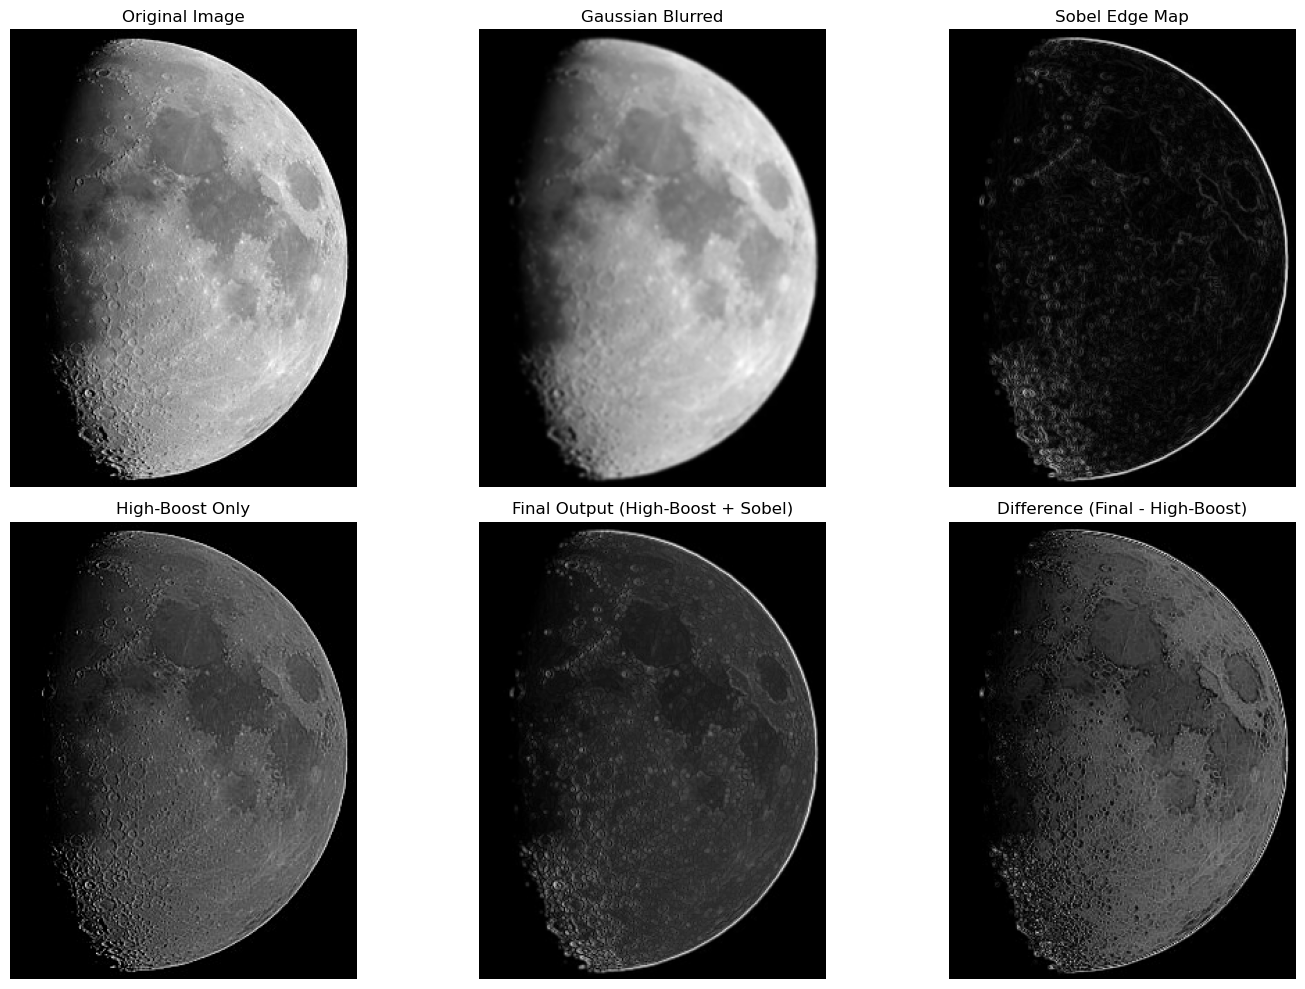

  Test case 3: High enhancement (A=2.0, alpha=0.8)
  Test case 4: alpha=0 (High-Boost only) (A=1.5, alpha=0.0)
  Test case 5: alpha=1 (Sobel only) (A=1.5, alpha=1.0)

All outputs saved to 'outputs/' directory


In [23]:
if __name__ == "__main__":
    main()